In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

features = pd.read_csv('../data/updated_features_volume.csv')

VOLUME_ORDER  = ['very_small', 'small', 'medium', 'large', 'very_large']
VOLUME_COLORS = {
    'very_small': '#264653',
    'small': '#2a9d8f',
    'medium': '#e9c46a',
    'large': '#e76f51',
    'very_large': '#1d3557',
}

print(features['volume_class'].value_counts())
print('\nAmino acids per class:')
for cls in VOLUME_ORDER:
    aas = sorted(features.loc[features['volume_class'] == cls, 'amino_acid'].unique())
    print(f'  {cls:6s}: {", ".join(aas)}')

volume_class
large         10004
small          9923
medium         8062
very_small     6085
very_large     5922
Name: count, dtype: int64

Amino acids per class:
  very_small: A, G, S
  small : C, D, N, P, T
  medium: E, H, Q, V
  large : I, K, L, M, R
  very_large: F, W, Y


### Mean current distribution by volume class

/var/folders/ck/1nxbm2p53kx6t3f6p6jhsfxc0000gn/T/ipykernel_72264/4272636550.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=features, x='volume_class', y='mean_current',


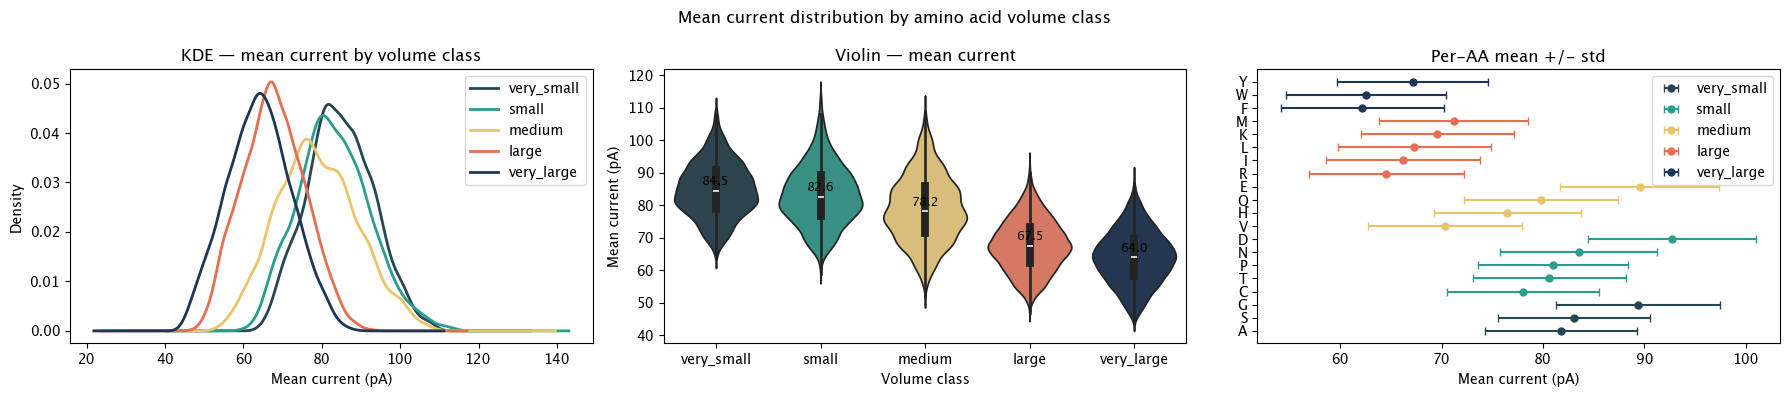

                count   mean    std    min    25%    50%    75%     max
volume_class                                                           
very_small     6085.0  84.78   8.40  63.57  78.88  84.46  90.65  110.06
small          9923.0  83.13   9.24  58.88  76.73  82.60  89.21  114.99
medium         8062.0  78.85  10.22  51.85  71.48  78.25  85.85  110.36
large         10004.0  67.73   7.91  46.80  62.05  67.54  73.22   93.64
very_large     5922.0  64.01   8.11  44.15  58.24  63.96  69.56   88.83


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# KDE overlay
ax = axes[0]
for cls in VOLUME_ORDER:
    grp = features[features['volume_class'] == cls]
    grp['mean_current'].plot.kde(ax=ax, label=cls, color=VOLUME_COLORS[cls], linewidth=2)
ax.set_xlabel('Mean current (pA)')
ax.set_title('KDE — mean current by volume class')
ax.legend()

# Violin
ax = axes[1]
sns.violinplot(data=features, x='volume_class', y='mean_current',
               order=VOLUME_ORDER, palette=VOLUME_COLORS, ax=ax)
for i, cls in enumerate(VOLUME_ORDER):
    med = features.loc[features['volume_class'] == cls, 'mean_current'].median()
    ax.text(i, med + 1, f'{med:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Violin — mean current')
ax.set_xlabel('Volume class')
ax.set_ylabel('Mean current (pA)')

# Per-amino-acid dot plot (mean +/- std)
ax = axes[2]
aa_stats = (
    features.groupby(['amino_acid', 'volume_class'])['mean_current']
    .agg(mean='mean', std='std')
    .reset_index()
    .sort_values('mean')
)
for cls in VOLUME_ORDER:
    sub = aa_stats[aa_stats['volume_class'] == cls]
    ax.errorbar(sub['mean'], sub['amino_acid'], xerr=sub['std'],
                fmt='o', color=VOLUME_COLORS[cls], label=cls, capsize=3, markersize=5)
ax.set_xlabel('Mean current (pA)')
ax.set_title('Per-AA mean +/- std')
ax.legend()

plt.suptitle('Mean current distribution by amino acid volume class', fontsize=12)
plt.tight_layout()
plt.show()

print(features.groupby('volume_class')['mean_current'].describe().loc[VOLUME_ORDER].round(2))

### KDE pairwise overlap between volume classes

In [10]:
from itertools import combinations

x_lin = np.linspace(features['mean_current'].min() - 5, features['mean_current'].max() + 5, 1000)
kdes = {
    cls: gaussian_kde(features.loc[features['volume_class'] == cls, 'mean_current'].values)(x_lin)
    for cls in VOLUME_ORDER
}

print('Pairwise KDE overlap (0 = no overlap, 1 = identical):')
for cls_a, cls_b in combinations(VOLUME_ORDER, 2):
    overlap = np.trapezoid(np.minimum(kdes[cls_a], kdes[cls_b]), x_lin)
    print(f'  {cls_a:6s} vs {cls_b:6s}: {overlap:.4f}')

Pairwise KDE overlap (0 = no overlap, 1 = identical):
  very_small vs small : 0.9042
  very_small vs medium: 0.7308
  very_small vs large : 0.3169
  very_small vs very_large: 0.2282
  small  vs medium: 0.8134
  small  vs large : 0.3874
  small  vs very_large: 0.2868
  medium vs large : 0.5602
  medium vs very_large: 0.4409
  large  vs very_large: 0.8246


### Data-driven clustering of AAs by mean current (KMeans, k=4)

In [12]:
from sklearn.cluster import KMeans

aa_means = features.groupby('amino_acid')['mean_current'].mean().reset_index()

km = KMeans(n_clusters=6, random_state=42)
aa_means['cluster'] = km.fit_predict(aa_means[['mean_current']])

# Sort clusters by mean current so cluster 0 = lowest, 3 = highest
cluster_order = (
    aa_means.groupby('cluster')['mean_current'].mean()
    .sort_values().index.tolist()
)
rank_map = {old: new for new, old in enumerate(cluster_order)}
aa_means['cluster'] = aa_means['cluster'].map(rank_map)

aa_means = aa_means.sort_values('mean_current').reset_index(drop=True)
print(aa_means)

   amino_acid  mean_current  cluster
0           F     62.199202        0
1           W     62.559931        0
2           R     64.550742        1
3           I     66.190279        1
4           Y     67.159610        1
5           L     67.332361        1
6           K     69.579323        2
7           V     70.306743        2
8           M     71.188241        2
9           H     76.505522        3
10          C     78.022354        3
11          Q     79.815661        3
12          T     80.648428        4
13          P     80.983215        4
14          A     81.810295        4
15          S     83.064764        4
16          N     83.519550        4
17          G     89.381121        5
18          E     89.543909        5
19          D     92.735020        5


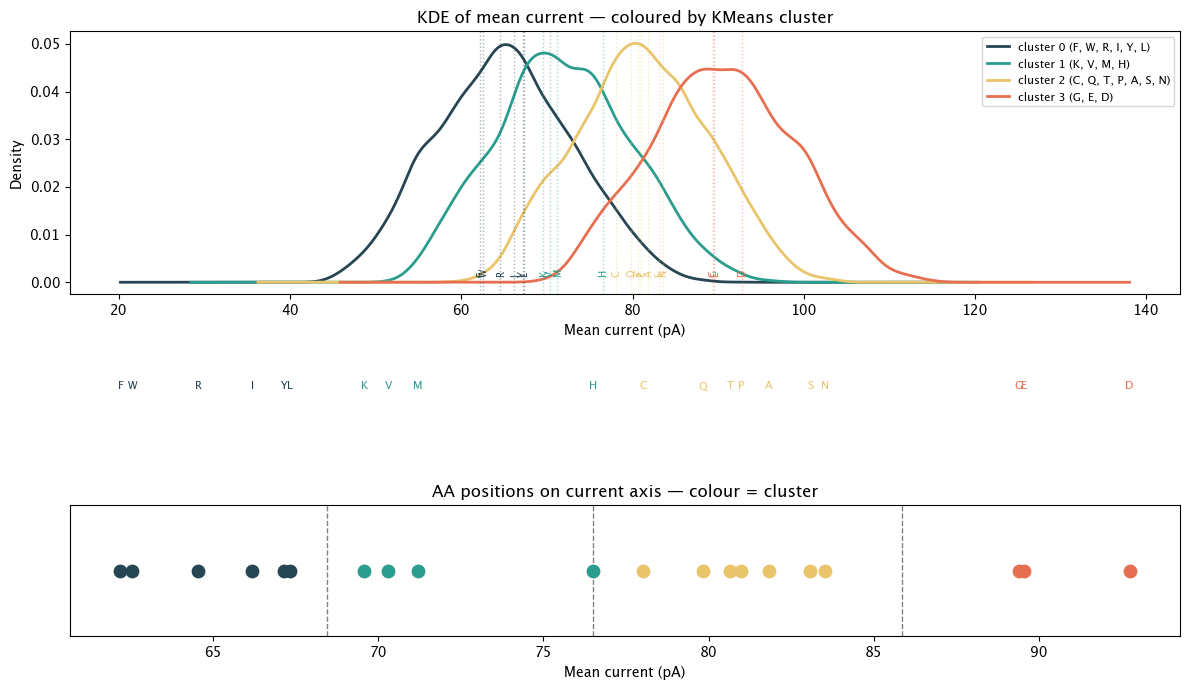

In [7]:
CLUSTER_COLORS = ['#264653', '#2a9d8f', '#e9c46a', '#e76f51']

fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'height_ratios': [2, 1]})

# Top: KDE of full distribution coloured by cluster, with AA labels on x-axis
ax = axes[0]
for c in range(4):
    aas_in_cluster = aa_means.loc[aa_means['cluster'] == c, 'amino_acid'].tolist()
    subset = features[features['amino_acid'].isin(aas_in_cluster)]
    subset['mean_current'].plot.kde(ax=ax, color=CLUSTER_COLORS[c],
                                    linewidth=2, label=f'cluster {c} ({", ".join(aas_in_cluster)})')

# Mark each AA's mean with a tick
for _, row in aa_means.iterrows():
    ax.axvline(row['mean_current'], color=CLUSTER_COLORS[int(row['cluster'])],
               alpha=0.4, linewidth=1, linestyle=':')
    ax.text(row['mean_current'], ax.get_ylim()[1] * 0.02, row['amino_acid'],
            ha='center', va='bottom', fontsize=7, rotation=90,
            color=CLUSTER_COLORS[int(row['cluster'])])

ax.set_xlabel('Mean current (pA)')
ax.set_title('KDE of mean current — coloured by KMeans cluster')
ax.legend(fontsize=8, loc='upper right')

# Bottom: dot plot — each AA as a point on a 1-D axis coloured by cluster
ax = axes[1]
for _, row in aa_means.iterrows():
    c = int(row['cluster'])
    ax.scatter(row['mean_current'], 0, color=CLUSTER_COLORS[c], s=80, zorder=3)
    ax.text(row['mean_current'], 0.15, row['amino_acid'],
            ha='center', va='bottom', fontsize=8, color=CLUSTER_COLORS[c])

# Draw cluster boundaries (midpoints between consecutive cluster means)
centroids = sorted(km.cluster_centers_[cluster_order, 0])
for i in range(len(centroids) - 1):
    boundary = (centroids[i] + centroids[i + 1]) / 2
    ax.axvline(boundary, color='grey', linestyle='--', linewidth=1)

ax.set_yticks([])
ax.set_xlabel('Mean current (pA)')
ax.set_title('AA positions on current axis — colour = cluster')

plt.tight_layout()
plt.show()

In [4]:
from sklearn.cluster import KMeans
import pandas as pd

# Get mean current per AA from your features
aa_means = features.groupby('amino_acid')['mean_current'].mean().reset_index()

# Cluster into k groups based purely on current value
km = KMeans(n_clusters=4, random_state=42)
aa_means['data_driven_class'] = km.fit_predict(aa_means[['mean_current']])

print(aa_means.sort_values('mean_current'))

   amino_acid  mean_current  data_driven_class
4           F     62.199202                  0
18          W     62.559931                  0
14          R     64.550742                  0
7           I     66.190279                  0
19          Y     67.159610                  0
9           L     67.332361                  0
8           K     69.579323                  3
17          V     70.306743                  3
10          M     71.188241                  3
6           H     76.505522                  3
1           C     78.022354                  1
13          Q     79.815661                  1
16          T     80.648428                  1
12          P     80.983215                  1
0           A     81.810295                  1
15          S     83.064764                  1
11          N     83.519550                  1
5           G     89.381121                  2
3           E     89.543909                  2
2           D     92.735020                  2
